In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
from functions.plot_function import (plot_joint_trajectory,
                                     plot_joint_index,
                                     animate_joint_index)
from sklearn.decomposition import PCA
from functions.load_data import load_data, load_multi_data

import joblib
import os

In [ ]:
CASE = 'flat'
FOLDER = 'cot'
TRIAL = [0,1,2,3,4,5,6,7,8,9]
MODEL = "hebb"
BASE_PATH = f'C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\sim2real_plot\\logs'

flat_hebb = load_multi_data("flat", FOLDER, "hebb", TRIAL, BASE_PATH)
flat_ff = load_multi_data("flat", FOLDER, "ff", TRIAL, BASE_PATH)

# s15lr_hebb = load_multi_data("s15lr", FOLDER, "hebb", TRIAL, BASE_PATH)
# s15lr_ff = load_multi_data("s15lr", FOLDER, "ff", TRIAL, BASE_PATH)

s20l_hebb = load_multi_data("s20l", FOLDER, "hebb", TRIAL, BASE_PATH)
s20l_ff = load_multi_data("s20l", FOLDER, "ff", TRIAL, BASE_PATH)

In [ ]:
# ---------
GECKO_MASS = 2.45 # kg
DISTANCE = 1.5 # m

# ---------
RAW_TO_CURRENT = 2.69 # mA
TORQUE_CONSTANT =  0.5494505495
IDLE_CURRENT = 0.18

# current = TORQUE_CONSTANT * torque + IDLE_CURRENT
# torque  = (current - IDLE_CURRENT) / TORQUE_CONSTANT

# -----------

RAW_TO_RPM = 0.229
RPM_TO_RADPS = 2 * np.pi / 60
RAW_TO_RADPS = 0.229 * 2 * np.pi / 60

In [ ]:
def walk_velocity(data, index , distance):
    walk_velocity = distance / np.sum(np.array(data[index]['dt'])) # m/s
    return walk_velocity
# cot = calculate_cot(data, 0, GECKO_MASS, DISTANCE)
    

In [ ]:
vel_hebb_flat = np.array([walk_velocity(flat_hebb, i, DISTANCE) for i in range(len(flat_hebb))])
vel_ff_flat = np.array([walk_velocity(flat_ff, i, DISTANCE) for i in range(len(flat_ff))])

vel_hebb_s15lr = np.array([walk_velocity(s15lr_hebb, i, DISTANCE) for i in range(len(s15lr_hebb))])
vel_ff_s15lr = np.array([walk_velocity(s15lr_ff, i, DISTANCE) for i in range(len(s15lr_ff))])

vel_hebb_s20l = np.array([walk_velocity(s20l_hebb, i, DISTANCE) for i in range(len(s20l_hebb))])
vel_ff_s20l = np.array([walk_velocity(s20l_ff, i, DISTANCE) for i in range(len(s20l_ff))])


vel_hebb_flat = np.array([walk_velocity(flat_hebb, i, DISTANCE) for i in range(len(flat_hebb))])
vel_ff_flat = np.array([walk_velocity(flat_ff, i, DISTANCE) for i in range(len(flat_ff))])

vel_hebb_s15lr = np.array([walk_velocity(s15lr_hebb, i, DISTANCE) for i in range(len(s15lr_hebb))])
vel_ff_s15lr = np.array([walk_velocity(s15lr_ff, i, DISTANCE) for i in range(len(s15lr_ff))])

vel_hebb_s20l = np.array([walk_velocity(s20l_hebb, i, DISTANCE) for i in range(len(s20l_hebb))])
vel_ff_s20l = np.array([walk_velocity(s20l_ff, i, DISTANCE) for i in range(len(s20l_ff))])



In [13]:
from scipy import stats

def mean_ci95(x):
    x = np.asarray(x)
    n = len(x)
    m = x.mean()
    sem = x.std(ddof=1) / np.sqrt(n)
    h = sem * stats.t.ppf(0.975, n - 1)  # 95% CI half-width, n=10 -> t~2.26
    return m, h

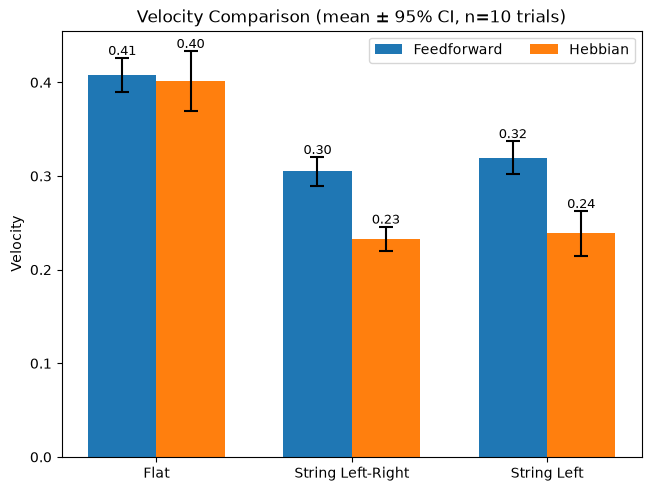

In [20]:

case = ("Flat", "String Left-Right", "String Left")
groups = {
    'Feedforward': (vel_ff_flat, vel_ff_s15lr, vel_ff_s20l),
    'Hebbian': (vel_hebb_flat, vel_hebb_s15lr, vel_hebb_s20l),
}



x = np.arange(len(case))
width = 0.35

fig, ax = plt.subplots(layout='constrained')
for i, (label, arrs) in enumerate(groups.items()):
    means, halfwidths = zip(*(mean_ci95(a) for a in arrs))
    offset = (i - (len(groups) - 1) / 2) * width
    bars = ax.bar(x + offset, means, width, yerr=halfwidths, capsize=5,
                   label=label, error_kw=dict(elinewidth=1.5, capthick=1.5))
    for xi, m, h in zip(x + offset, means, halfwidths):
        ax.text(xi, m + h, f'{m:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x, case)
ax.set_ylabel('Velocity')
ax.set_title('Velocity Comparison (mean ± 95% CI, n=10 trials)')
ax.legend(loc='upper right', ncols=2)

plt.show()